<a target="_blank" rel="noopener noreferrer" href="https://colab.research.google.com/github/ccaudek/ds4psy_2023/blob/main/05_reglin_4.ipynb">![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)</a>

(bambi-notebook)=
# Zucchero sintattico

I modelli lineari sono così ampiamente utilizzati che sono stati sviluppati appositamente una sintassi, dei metodi e delle librerie per la regressione. Una di queste librerie è `bambi` (BAyesian Model-Building Interface). `bambi` è un pacchetto Python progettato per adattare modelli gerarchici generalizzati lineari (di cui il modello lineare bivariato è un caso particolare), utilizzando una sintassi simile a quella presente nei pacchetti R, come `lme4`, `nlme`, `rstanarm` o `brms`. `bambi` si basa su PyMC, ma offre un'API di livello superiore.

In questo capitolo esploreremo come condurre un'analisi di regressione utilizzando `bambi` invece di PyMC.

## Preparazione del Notebook

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import bambi as bmb
import arviz as az
import xarray as xr
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=Warning)

In [2]:
%config InlineBackend.figure_format = 'retina'
# Initialize random number generator
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

## BAyesian Model-Building Interface 

Simuliamo i dati esattamente come abbiamo fatto nel capitolo precedente.

In [3]:
size = 200
true_intercept = 1
true_slope = 2

x = np.linspace(0, 1, size)
# y = a + b*x
true_regression_line = true_intercept + true_slope * x
# add noise
y = true_regression_line + rng.normal(scale=0.5, size=size)

data = pd.DataFrame(dict(x=x, y=y))

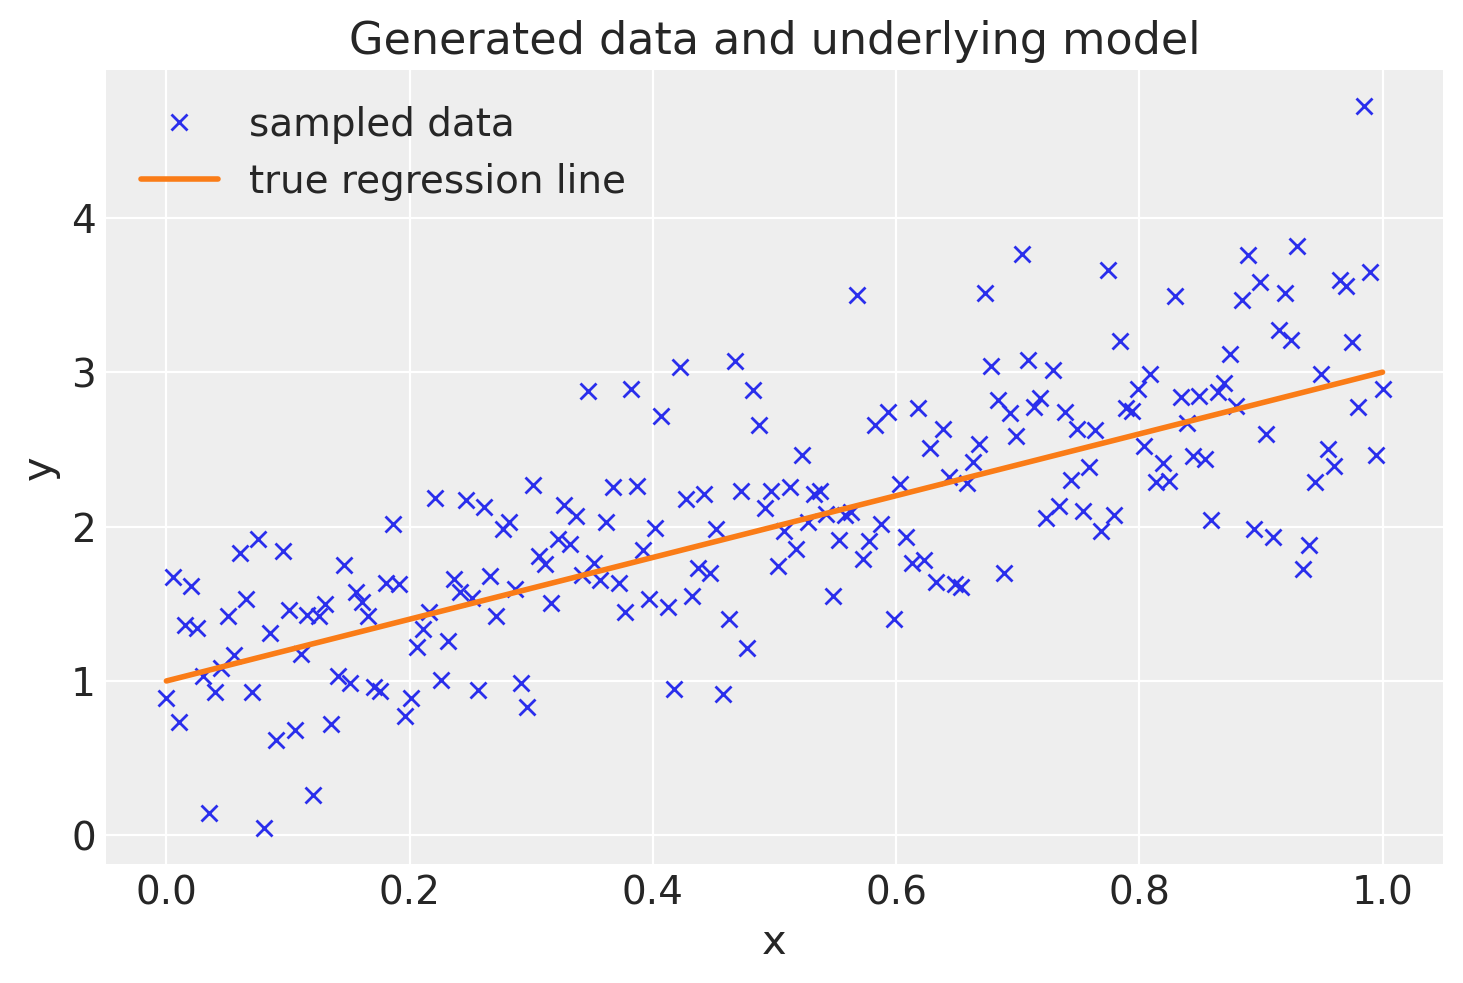

In [4]:
plt.plot(x, y, "x", label="sampled data")
plt.plot(x, true_regression_line, label="true regression line", lw=2.0)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Generated data and underlying model")
plt.legend(loc=0);

PyMC ha una sintassi molto semplice ed espressiva che ci consente di costruire modelli arbitrari. Questo di solito è un vantaggio, ma può essere anche un peso. Bambi, invece, si concentra sui modelli di regressione, e questa restrizione porta a una sintassi e a caratteristiche più focalizzate. Bambi utilizza la sintassi di Wilkinson {cite:p}`wilkinson1973symbolic`. Inoltre, `bambi` implementa delle distribuzioni a priori ottimizzate, eliminando così la necessità di definirle esplicitamente. Tuttavia, se si preferisce un maggiore controllo sulle distribuzioni a priori, è possibile specificarle manualmente.

Per replicare il modello descritto nel capitolo {ref}`reglin-pymc-notebook`, possiamo utilizzare la seguente istruzione. 

In [5]:
model = bmb.Model("y ~ x", data)

Sul lato sinistro della tilde (∼), abbiamo la variabile dipendente, e sul lato destro, le variabili indipendenti. Con questa sintassi, stiamo semplicemente specificando la media (μ nel modello lm di PyMC). Per impostazione predefinita, Bambi assume che la verosimiglianza sia gaussiana; è possibile modificarla con l'argomento `family`. La sintassi della formula non specifica la distribuzione delle priors, ma solo come sono associate le variabili dipendenti e indipendenti. Bambi definirà automaticamente delle priors (molto) debolmente informative per noi. Possiamo ottenere ulteriori informazioni stampando il modello Bambi.

In [6]:
print(model)

       Formula: y ~ x
        Family: gaussian
          Link: mu = identity
  Observations: 200
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 2.0759, sigma: 3.9401)
            x ~ Normal(mu: 0.0, sigma: 6.8159)
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 0.791)


La descrizione inizia mostrando la formula utilizzata per definire il modello, `y ~ x`, che indica come la variabile dipendente `y` è predetta dalla variabile indipendente `x` in una relazione lineare. La seconda riga specifica che si sta utilizzando una distribuzione gaussiana (normale) come funzione di verosimiglianza per il modello, il che implica l'assunzione che i residui del modello (le differenze tra i valori osservati e i valori predetti) seguano una distribuzione normale.

La terza riga menziona la funzione di collegamento, in questo caso l'identità, che non applica alcuna trasformazione al valore atteso della variabile dipendente. Questo è caratteristico dei modelli lineari, dove il valore atteso di `y` è direttamente modellato come una combinazione lineare delle variabili indipendenti (`E(Y) = \alpha + \beta x`). È importante notare che, nei modelli lineari generalizzati, la funzione di collegamento gioca un ruolo cruciale nel collegare il valore atteso della variabile risposta alla combinazione lineare delle variabili predittive.

Segue il numero di osservazioni utilizzate per adattare il modello, indicando la dimensione del dataset su cui il modello è stato allenato.

La parte successiva dell'output dettaglia i priors utilizzati per i parametri del modello. In Bambi, i priors sono assunzioni a priori sui valori dei parametri prima di osservare i dati. Questi priors aiutano a guidare l'inferenza, soprattutto in presenza di dati limitati o per regolarizzare il modello. L'intercetta (Intercept) ha un prior normale con media (`mu`) 2.0759 e deviazione standard (`sigma`) 3.9401, indicando la posizione iniziale attesa della linea di regressione e quanto ci si aspetta che vari. Il coefficiente della variabile `x` ha anch'esso un prior normale, centrato in zero con una deviazione standard ampia (6.8159), riflettendo incertezza su quale possa essere il vero effetto di `x` su `y` senza presupporre una direzione specifica dell'effetto.

La sezione finale riguarda i parametri ausiliari del modello, in questo caso il parametro `sigma` della distribuzione gaussiana, che rappresenta la deviazione standard dei residui del modello. Questo ha un prior HalfStudentT, che è una distribuzione che ammette solo valori positivi (essendo la deviazione standard sempre positiva), con un grado di libertà (`nu`) 4.0 e una scala (`sigma`) 0.791. Questo prior è scelto per la sua flessibilità e la capacità di gestire dati con potenziali outlier.

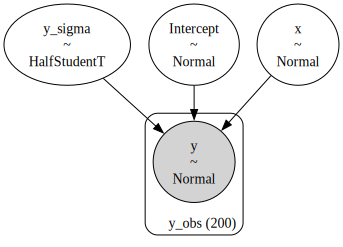

In [7]:
model.build()
model.graph()

Eseguiamo il campionamento MCMC.

In [8]:
idata = model.fit(method="nuts_numpyro", idata_kwargs={"log_likelihood": True})

  0%|                                                                              | 0/2000 [00:00<?, ?it/s]

Compiling.. :   0%|                                                                | 0/2000 [00:00<?, ?it/s]

  0%|                                                                              | 0/2000 [00:00<?, ?it/s]

Compiling.. :   0%|                                                                | 0/2000 [00:00<?, ?it/s]

  0%|                                                                              | 0/2000 [00:00<?, ?it/s]

...

Running chain 0:   0%|                                                             | 0/2000 [00:02<?, ?it/s]

Running chain 0: 100%|█████████████████████████████████████████████████| 2000/2000 [00:02<00:00, 966.82it/s]


Running chain 1: 100%|█████████████████████████████████████████████████| 2000/2000 [00:02<00:00, 967.56it/s]


Running chain 2: 100%|█████████████████████████████████████████████████| 2000/2000 [00:02<00:00, 968.65it/s]


Running chain 3: 100%|█████████████████████████████████████████████████| 2000/2000 [00:02<00:00, 969.56it/s]

Le distribuzioni a posteriori dei parametri e i trace plot si ottengono con la seguente istruzione.

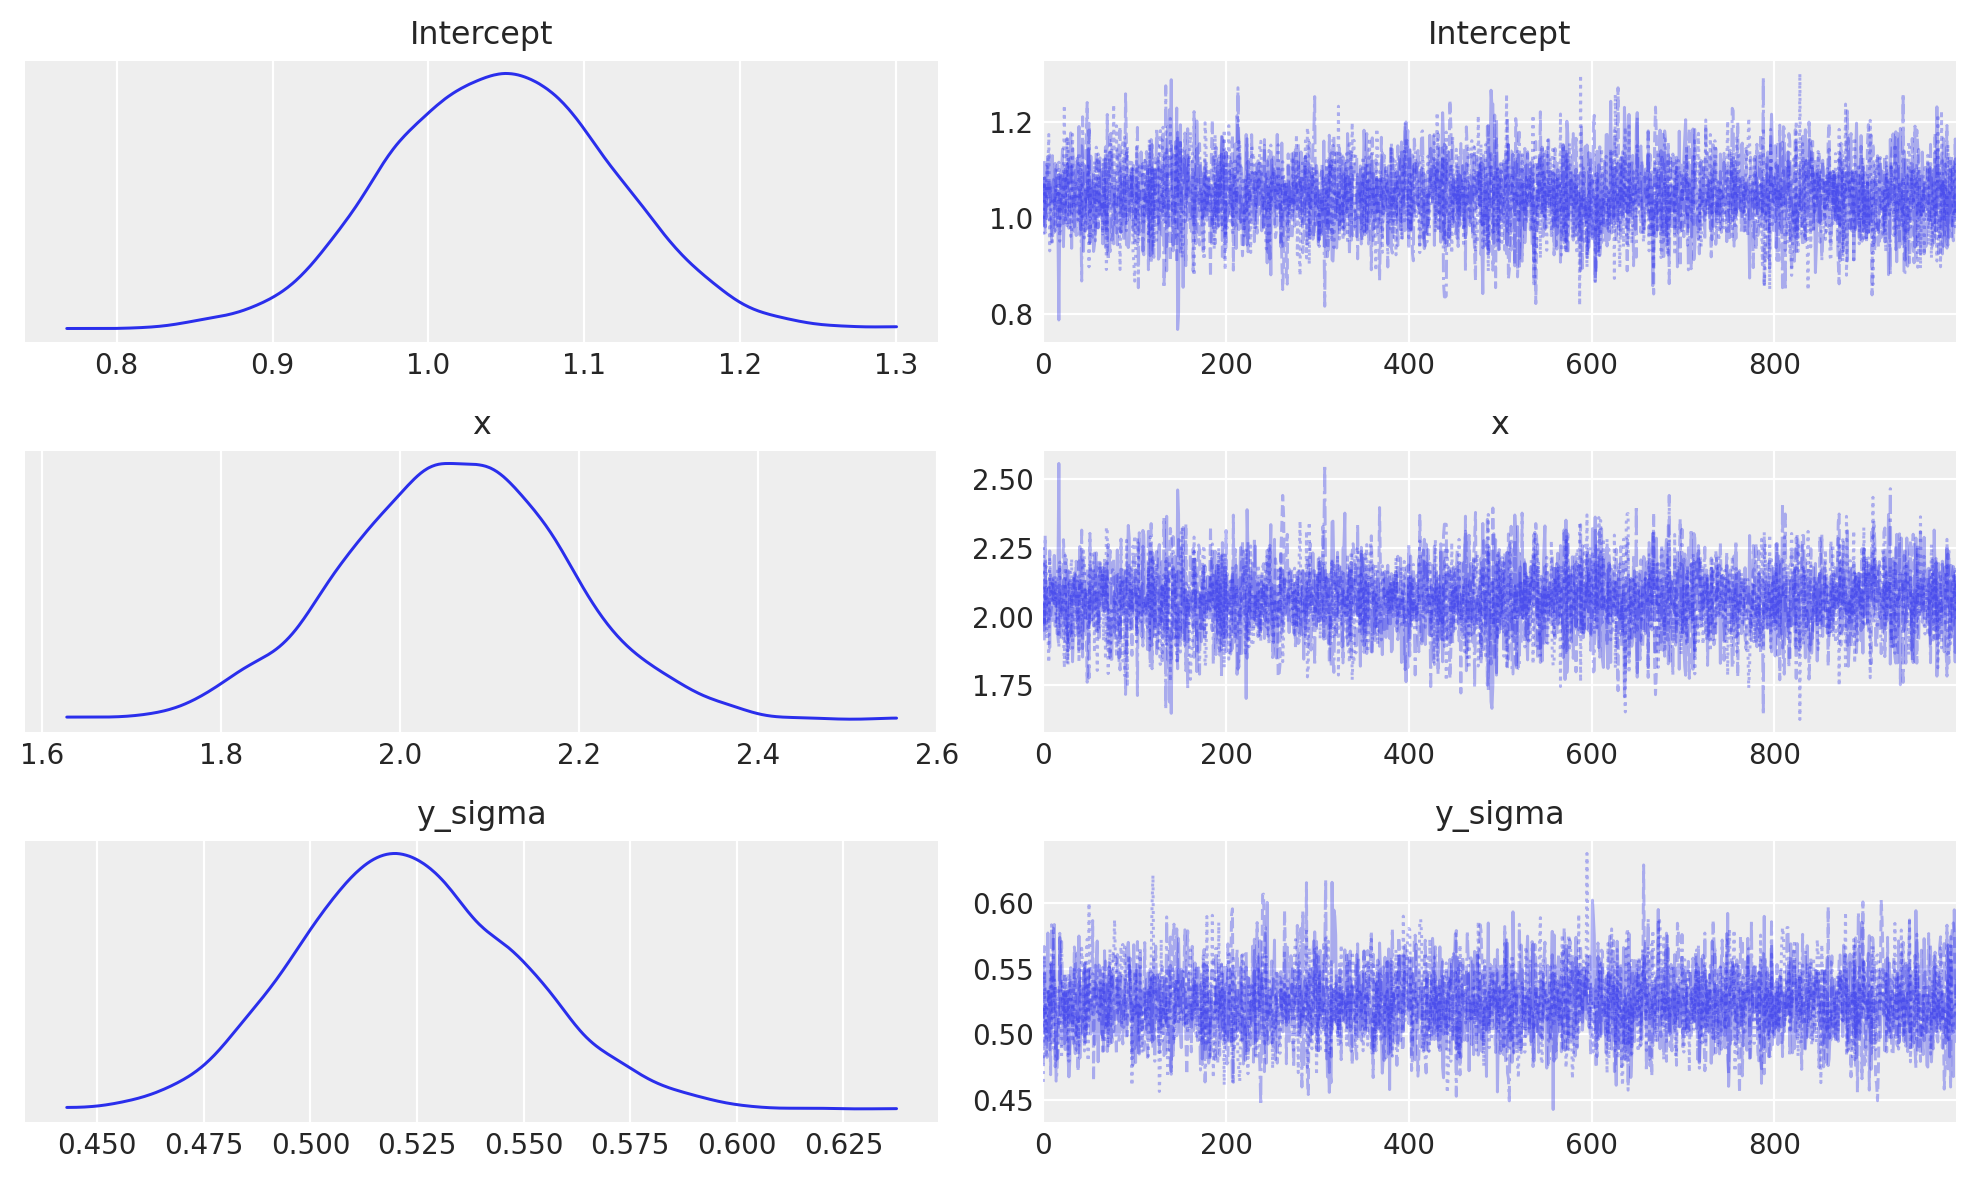

In [9]:
az.plot_trace(idata, combined=True, figsize=(10, 6))
plt.tight_layout();

Un sommario numerico delle distribuzioni a posteriori dei parametri si ottiene con `az.summary`.

In [10]:
az.summary(idata, round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,1.05,0.07,0.91,1.18,0.0,0.0,4207.58,3116.40,1.0
x,2.06,0.12,1.82,2.29,0.0,0.0,4162.39,3091.23,1.0
y_sigma,0.52,0.03,0.48,0.57,0.0,0.0,3845.28,2809.19,1.0


Si noti che i risultati replicano quelli ottenuti con PyMC.

Possiamo anche generare un grafico che descrive l'incertezza a posteriori delle predizioni del modello. 

La funzione `plot_predictions` del pacchetto Bambi serve per facilitare l'interpretazione dei modelli di regressione attraverso la visualizzazione grafica. Il metodo appartiene al sottomodulo `interpret` di Bambi e si concentra sulla rappresentazione delle previsioni generate dal modello.

Quando si esegue la funzione `plot_predictions` con i parametri specificati (`model`, `idata`, `["x"]`), essa produce un grafico che sintetizza le previsioni del modello in relazione a una o più variabili indipendenti. In questo caso, il parametro `model` indica il modello di regressione Bayesiana costruito con Bambi, `idata` rappresenta i dati inferenziali (ottenuti tramite il fit del modello), e `["x"]` specifica la variabile indipendente da considerare per il grafico.

L'output visuale generato da questa funzione mostra due componenti principali:

1. **Media Posteriore di `y`**: Il grafico include una linea che rappresenta la media posteriore della variabile dipendente (`y`) rispetto alla variabile indipendente specificata (`x`). La media posteriore è una stima centrale delle previsioni del modello, che riflette la posizione più probabile dei valori di `y` data l'evidenza fornita dai dati.

2. **Intervallo di Densità più Alta del 94%**: Attorno alla linea della media posteriore, il grafico mostra anche un'area ombreggiata che rappresenta l'intervallo di densità più alta (HDI) del 94%. Questo intervallo è un modo per quantificare l'incertezza delle previsioni del modello. L'HDI del 94% significa che, data la distribuzione posteriore delle previsioni di `y`, c'è il 94% di probabilità che il valore vero di `y` cada all'interno di questo intervallo per un dato valore di `x`. Questo fornisce una misura visiva dell'incertezza associata alle stime del modello.

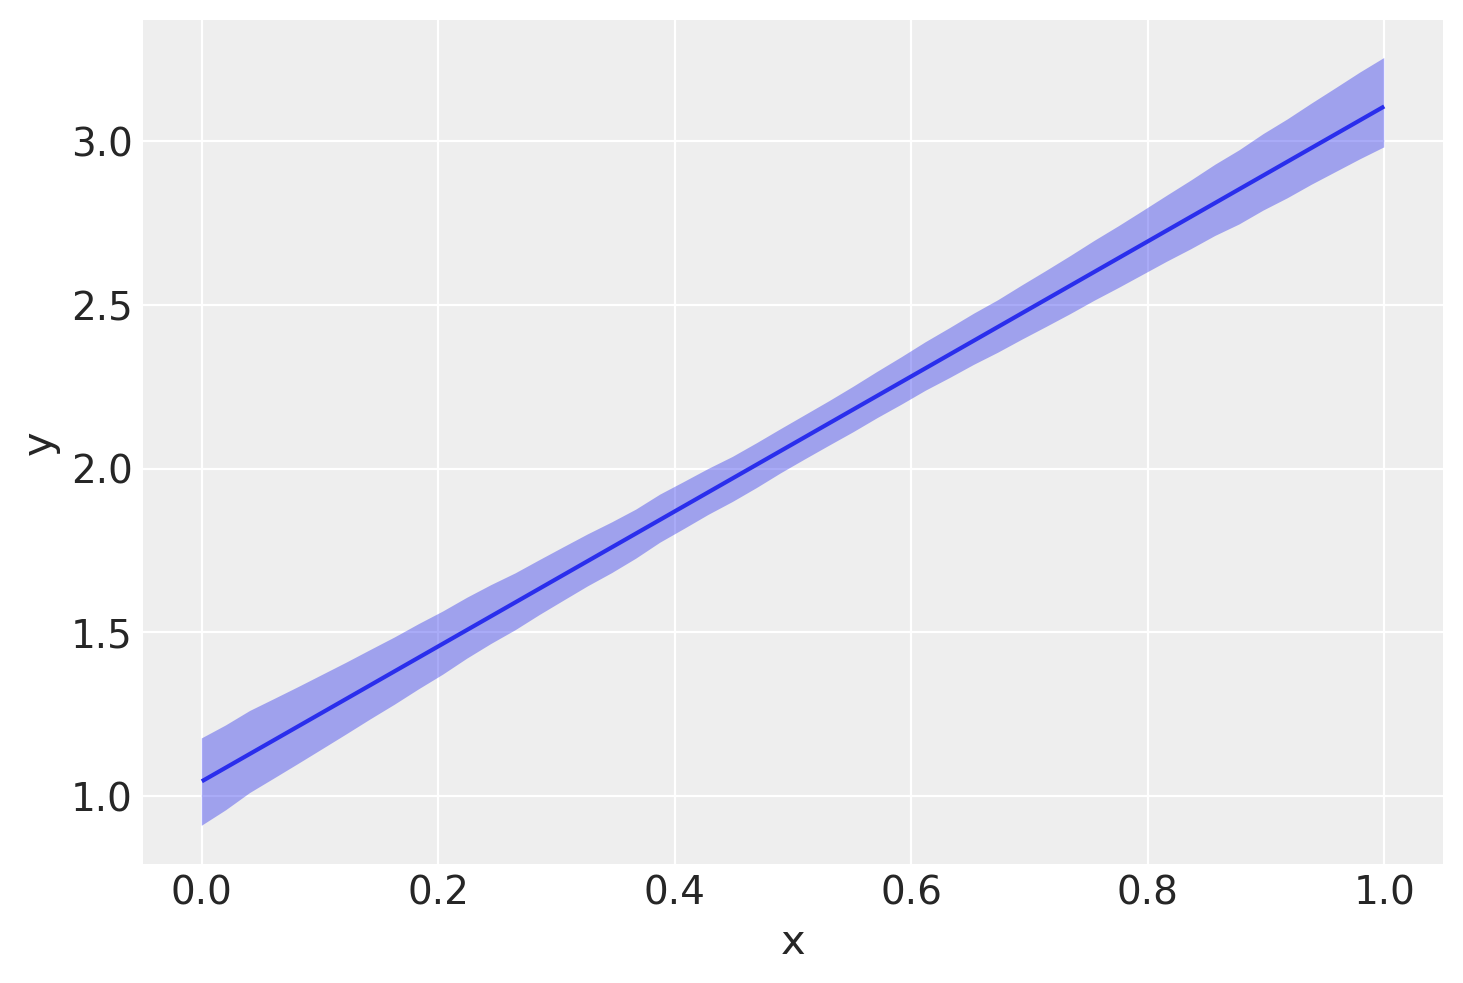

In [11]:
bmb.interpret.plot_predictions(model, idata, ["x"]);

In alternativa, possiamo visualizzare in maniera esplicita l'incertezza delle stime di regressione utilizzando la libreria ArviZ. Iniziamo creando manualmente la variabile `y_model` che combina intercette e pendenze estratte dalla distribuzione a posteriori, e poi visualizziamo diverse linee di regressione basate su campioni di queste stime. In questo modo possiamo osservare direttamente come varia la relazione tra `x` e `y` secondo il nostro modello e i dati analizzati. Questo metodo offre un'illustrazione grafica potente dell'incertezza e della variabilità delle previsioni del modello.

In [12]:
idata.posterior["y_model"] = idata.posterior["Intercept"] + idata.posterior["x"] * xr.DataArray(x)

1. **Creazione di una Variabile Modellata `y_model`**:
   - `idata.posterior["y_model"] = idata.posterior["Intercept"] + idata.posterior["x"] * xr.DataArray(x)`
   - In questo passaggio, stiamo costruendo manualmente una variabile `y_model` all'interno dell'oggetto `idata` che contiene i risultati inferenziali di un modello Bayesian. La variabile `y_model` rappresenta le previsioni del modello di regressione per la variabile dipendente `y`, calcolate come la somma dell'intercetta (`Intercept`) e il prodotto tra i coefficienti della variabile indipendente `x` e i valori di `x` stessi. `xr.DataArray(x)` converte i valori di `x` in un formato compatibile con xarray, facilitando operazioni vettorializzate con i coefficienti posteriori.

2. **Visualizzazione con `plot_lm` di ArviZ**:
   - `az.plot_lm(idata=idata, y="y", num_samples=100, y_model="y_model")`
   - Questo comando utilizza la funzione `plot_lm` della libreria ArviZ per visualizzare le linee di regressione predittive posteriori. I parametri specificati indicano che il grafico deve essere basato sui dati inferenziali contenuti in `idata`, utilizzando la variabile `y_model` come modello di regressione. Il parametro `num_samples=100` specifica di estrarre e visualizzare 100 campioni dalla distribuzione a posteriori, generando così un insieme di linee di regressione che riflettono la varietà delle possibili pendenze e intercette secondo la nostra inferenza Bayesiana.

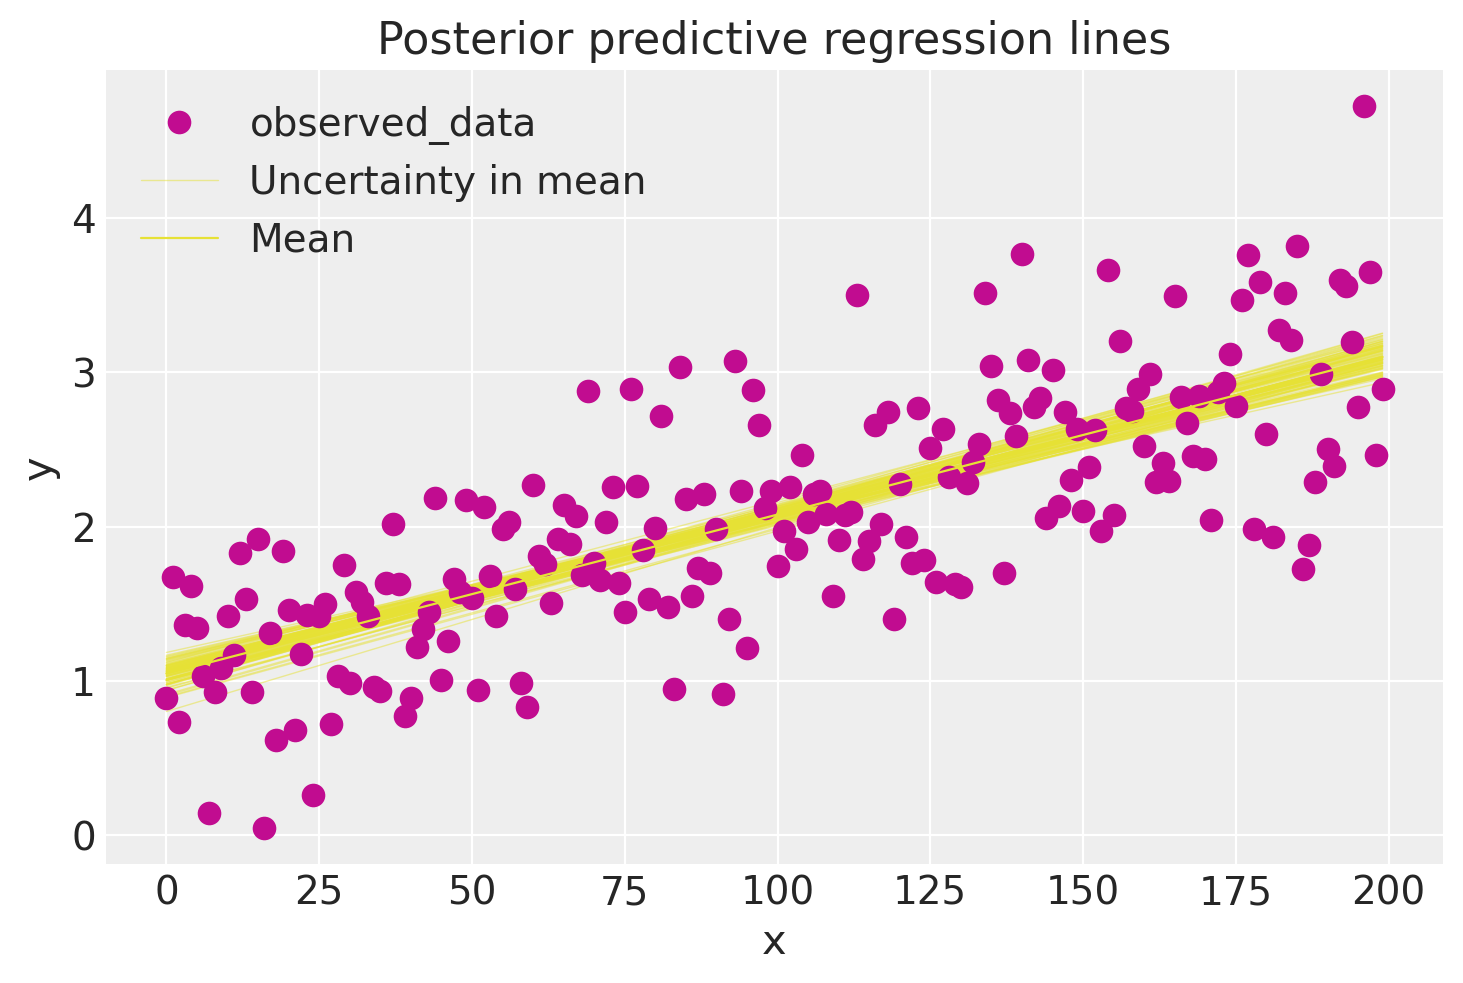

In [13]:
az.plot_lm(idata=idata, y="y", num_samples=100, y_model="y_model")
plt.title("Posterior predictive regression lines")
plt.xlabel("x");

Come abbiamo già osservato in precedenza, le rette di regressione stimate si avvicinano notevolmente alla vera retta di regressione. Tuttavia, dato che stiamo lavorando con un campione di dati e non con l'intera popolazione, le stime dei parametri della retta di regressione, quali intercetta e pendenza, sono soggette a un certo grado di incertezza. Questa incertezza non è un difetto, ma una rappresentazione naturale dell'informazione limitata che abbiamo a disposizione, e nel grafico è visualizzata attraverso la variabilità delle rette di regressione.

## Watermark

In [14]:
%load_ext watermark
%watermark -n -u -v -iv -w -m -p jax

Last updated: Thu Mar 28 2024

Python implementation: CPython
Python version       : 3.11.8
IPython version      : 8.22.2

jax: 0.4.25

Compiler    : Clang 16.0.6 
OS          : Darwin
Release     : 23.4.0
Machine     : x86_64
Processor   : i386
CPU cores   : 8
Architecture: 64bit

xarray    : 2024.2.0
numpy     : 1.26.4
bambi     : 0.13.0
matplotlib: 3.8.3
arviz     : 0.17.1
pandas    : 2.2.1
seaborn   : 0.13.2

Watermark: 2.4.3

